# Model Evaluation in Machine Learning

**Student:** Prithvi Adipudi  
**Date:** July 1, 2026  
**Course:** AIT-535

---

## 1. Introduction

This notebook evaluates two classification models on the **Boston Housing** data set. The
models are the classification counterparts of the two families used in Topic 1: a linear
model (**Logistic Regression**) and a tree ensemble (**Random Forest**). Topic 1 predicted
the exact home value; this topic asks a *yes/no* question instead, so the linear regressor
becomes a logistic classifier and the forest regressor becomes a forest classifier. Same two
families, matched to the new problem type.

**The decision this notebook is built around.** Imagine the city wants to automatically flag
**high-value homes** — those worth more than the median — for a property-tax reassessment.
A model makes that call for every home. Two kinds of mistakes carry very different costs:

- A **false positive** flags a modest home as high-value, so its owner faces an unfair
  reassessment they can least afford.
- A **false negative** misses a genuinely high-value home, so the city loses revenue it was owed.

Every metric below is read through this decision, which keeps the numbers tied to a real
consequence rather than left as abstract scores.

## 2. Part 1 — Understanding Model Evaluation

A model that scores well in training can still fail in the real world. **Model evaluation** is
how we measure whether a trained model actually generalizes to data it has not seen, using a
held-out test set and a set of metrics. Good evaluation is what makes a model *trustworthy*:
it tells us not just *if* the model is right, but *how* it is wrong, which matters when the two
kinds of error cost different things.

No single number is enough. Accuracy alone can hide a model that ignores a rare class, so we
report several metrics that each expose a different weakness. The dropdowns below explain each
required metric and when it is the one to watch.

<details>
<summary><strong>Accuracy — the share of correct calls</strong></summary>

Accuracy is the fraction of predictions that are correct: (TP + TN) / all. It is the natural
first look, but it is **misleading when classes are imbalanced**. If 95% of homes were
below-median, a model that always says "below" scores 95% while being useless for flagging
high-value homes. Here the classes are almost even (about 50/50), so accuracy is meaningful —
but we still confirm with the metrics below.
</details>

<details>
<summary><strong>Precision — how many flagged homes were really high-value</strong></summary>

Precision is TP / (TP + FP): of all homes the model flagged as high-value, how many truly were.
**Low precision means many false positives** — modest homes wrongly reassessed. When the cost
of a false alarm is high (an unfair tax bill), precision is the metric to protect.
</details>

<details>
<summary><strong>Recall — how many true high-value homes we caught</strong></summary>

Recall is TP / (TP + FN): of all the genuinely high-value homes, how many the model found.
**Low recall means many false negatives** — high-value homes that slip through and cost the
city revenue. When missing a positive is expensive, recall is the metric to protect.
</details>

<details>
<summary><strong>F-Measure (F1) — the balance of the two</strong></summary>

F1 is the harmonic mean of precision and recall: 2 · (P · R) / (P + R). It is high only when
**both** are high, so it is the single best summary when false positives and false negatives
both matter, as they do here. The harmonic mean punishes a model that sacrifices one to inflate
the other.
</details>

<details>
<summary><strong>AUC-ROC — quality across every threshold</strong></summary>

The other metrics judge decisions at one cutoff. A classifier really outputs a *probability*,
and the ROC curve traces the trade-off between true-positive rate and false-positive rate as
that cutoff moves from 0 to 1. **AUC** is the area under it: 1.0 is perfect, 0.5 is coin-flip.
It answers "how well does the model *rank* homes by value," independent of where we set the
threshold, which makes it the fairest single-number comparison between two models.
</details>

<details>
<summary><strong>Hamming Loss — the fraction of wrong labels</strong></summary>

Hamming loss is the fraction of labels predicted incorrectly — for a single-label problem it is
simply **1 − accuracy**. It is included because it generalizes cleanly to multi-label problems,
and reporting it alongside accuracy is a standard sanity check: the two must sum to 1.
</details>

## 3. Imports

In [1]:
import subprocess, sys, os, glob, io, contextlib

def ensure(pkg):
    try:
        __import__(pkg); return
    except ImportError:
        pass
    for extra in ([], ['--break-system-packages']):
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'] + extra,
                                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            return
        except subprocess.CalledProcessError:
            continue

for pkg in ['sklearn', 'scipy']:
    ensure('scikit-learn' if pkg == 'sklearn' else pkg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, RepeatedStratifiedKFold)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, hamming_loss,
                             confusion_matrix, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
BLUE, GREEN, GOLD, RED = '#4C72B0', '#55A868', '#CCA43B', '#C44E52'

print('Libraries loaded.')

Libraries loaded.


## 4. Load the Data and Build the Target

The raw file is whitespace-delimited with **no header**, so the 14 canonical Boston Housing
column names are attached. The loader searches common locations (the notebook folder, the
current directory, and Downloads), matches any CSV whose name contains "boston", and
auto-detects whitespace vs comma delimiters. If it cannot find the file, it prints exactly
where it looked and which CSVs it saw. The 13 predictors describe each town; **MEDV** is the
median home value in $1000s. The classification target splits MEDV at its median:
**1 = above-median (high-value), 0 = at or below** — which keeps the two classes naturally balanced.

In [2]:
COLS = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS',
        'RAD','TAX','PTRATIO','B','LSTAT','MEDV']

def load_boston():
    """Find and load the Boston Housing CSV from any common location.

    Searches the notebook folder, the current working directory, Downloads,
    Desktop, and the home folder. Matches any CSV whose name contains
    'boston' (case-insensitive), and auto-detects whitespace- vs
    comma-delimited files. If nothing is found, it reports exactly where it
    looked and what CSVs it saw, so the fix is obvious.
    """
    try:
        here = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        here = os.getcwd()                      # notebooks have no __file__
    home = os.path.expanduser('~')
    search_dirs = [here, os.getcwd(),
                   os.path.join(home, 'Downloads'),
                   os.path.join(home, 'Desktop'),
                   home]
    # deduplicate while preserving order
    seen, dirs = set(), []
    for d in search_dirs:
        if d and d not in seen:
            seen.add(d); dirs.append(d)

    found_any = []
    for d in dirs:
        if not os.path.isdir(d):
            continue
        csvs = glob.glob(os.path.join(d, '*.csv'))
        found_any += csvs
        hits = [f for f in sorted(csvs) if 'boston' in os.path.basename(f).lower()]
        if hits:
            path = hits[0]
            # auto detect separator
            df = pd.read_csv(path, header=None, sep=r'\s+', names=COLS)
            if df.shape[1] != 14 or df['MEDV'].isna().all():
                df = pd.read_csv(path, header=None, names=COLS)
            print('Loaded:', os.path.basename(path))
            print('From  :', d)
            return df

    # nothing matched
    msg = ["Could not find a Boston Housing CSV.",
           "Looked in these folders:"]
    msg += ['  - ' + d for d in dirs if os.path.isdir(d)]
    if found_any:
        msg.append("CSV files I did see (rename one to include 'boston', "
                   "or move it next to this notebook):")
        msg += ['  - ' + os.path.basename(f) for f in sorted(set(found_any))]
    else:
        msg.append("No .csv files were found in any of those folders.")
    msg.append("")
    msg.append("Tip: the surest fix is to put the CSV in the SAME folder as this "
               "notebook, then restart the kernel and run again.")
    raise FileNotFoundError("\n".join(msg))

df = load_boston()

threshold = df['MEDV'].median()
y = (df['MEDV'] > threshold).astype(int)
X = df.drop(columns='MEDV')

print(f'Rows: {len(df)}   Predictors: {X.shape[1]}   Missing values: {int(df.isna().sum().sum())}')
print(f'Median MEDV (class threshold): {threshold:.1f}  ($1000s)')
print('Class balance -> above-median (1): {}   at/below (0): {}'.format(int(y.sum()), int((y == 0).sum())))
df.head()

Loaded: AIT-535-RS-T1-BostonHousing.csv
From  : /Users/prithviadipudi/Downloads/Model Evaluation
Rows: 506   Predictors: 13   Missing values: 0
Median MEDV (class threshold): 21.2  ($1000s)
Class balance -> above-median (1): 250   at/below (0): 256


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 5. Train/Test Split and the Two Models

A single **stratified** 75/25 split holds out a test set, with stratification so both the
training and test sets keep the same class ratio. Each model sits in a pipeline that
standardizes features first, so scaling is learned only from training data and never leaks
into the test set.

- **Model 1 — Logistic Regression:** the linear, interpretable baseline (classification
  sibling of Topic 1's linear regressor).
- **Model 2 — Random Forest:** a flexible ensemble that captures non-linear feature effects
  (classification sibling of Topic 1's forest regressor).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print('Train: {} rows   Test: {} rows'.format(len(X_train), len(X_test)))
print('Train class ratio: {:.2f}   Test class ratio: {:.2f}'.format(y_train.mean(), y_test.mean()))

logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

forest = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
])

models = {'Logistic Regression': logistic, 'Random Forest': forest}
for name, m in models.items():
    m.fit(X_train, y_train)
print('\nBoth models trained.')

Train: 379 rows   Test: 127 rows
Train class ratio: 0.49   Test class ratio: 0.50

Both models trained.


## 6. Part 2 — Performance Metrics

All six required metrics are computed on the held-out test set for both models. Each model
produces hard labels (for accuracy, precision, recall, F1, hamming loss) and a class
probability (for AUC-ROC). Every number below is calculated from the predictions — nothing is
entered by hand.

In [4]:
def evaluate(model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]          # P(high-value) for AUC
    return {
        'Accuracy'   : accuracy_score(y_te, pred),
        'AUC-ROC'    : roc_auc_score(y_te, proba),
        'Precision'  : precision_score(y_te, pred),
        'Recall'     : recall_score(y_te, pred),
        'F1'         : f1_score(y_te, pred),
        'Hamming Loss': hamming_loss(y_te, pred),
    }

scores = pd.DataFrame({name: evaluate(m, X_test, y_test) for name, m in models.items()}).round(3)
print('Held-out test metrics:\n')
print(scores.to_string())

# sanity check: hamming loss must equal 1 - accuracy
for name in models:
    assert abs(scores.loc['Hamming Loss', name] - (1 - scores.loc['Accuracy', name])) < 1e-9
print('\nSanity check passed: Hamming Loss = 1 - Accuracy for both models.')

Held-out test metrics:

              Logistic Regression  Random Forest
Accuracy                    0.906          0.882
AUC-ROC                     0.962          0.959
Precision                   0.918          0.900
Recall                      0.889          0.857
F1                          0.903          0.878
Hamming Loss                0.094          0.118

Sanity check passed: Hamming Loss = 1 - Accuracy for both models.


## 7. Part 2 — Comparing Evaluation Techniques

A single accuracy number hides *which* errors happen. Three techniques look at the same
predictions from different angles: the **confusion matrix** (where the errors fall), the
**ROC curve** (quality across all thresholds), and **cross-validation** (Section 8, whether
the score is stable). Together they give a fuller picture than any one alone.

### 7.1 Confusion matrices — where the errors fall

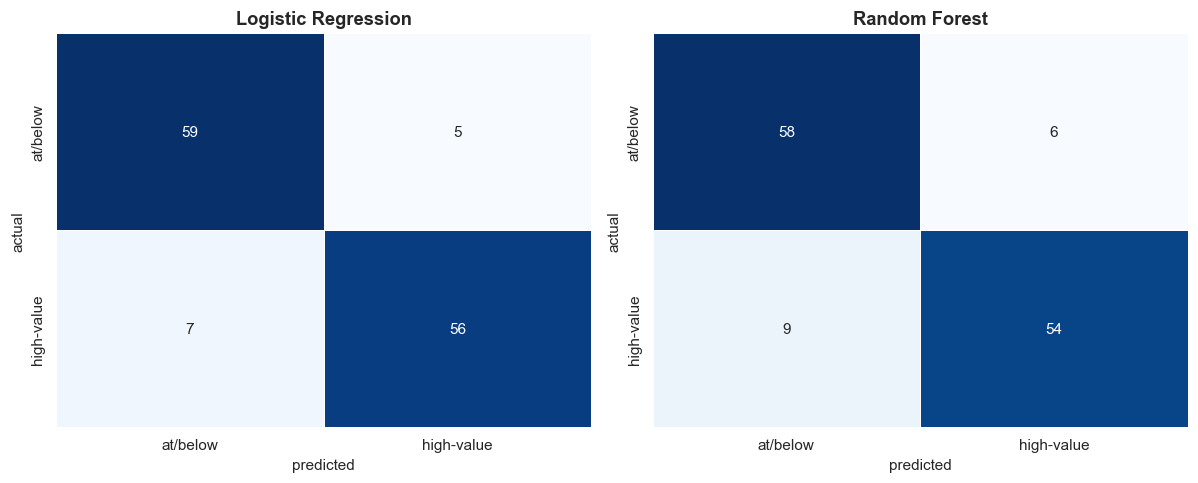

Logistic Regression  false positives (unfair reassessments): 5   false negatives (missed revenue): 7
Random Forest        false positives (unfair reassessments): 6   false negatives (missed revenue): 9


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, m) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, m.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['at/below', 'high-value'],
                yticklabels=['at/below', 'high-value'], linewidths=0.5, linecolor='white')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout(); plt.show()

# report the civic meaning of each off-diagonal, computed from the matrices
for name, m in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, m.predict(X_test)).ravel()
    print('{:20s} false positives (unfair reassessments): {}   '
          'false negatives (missed revenue): {}'.format(name, fp, fn))

### 7.2 ROC curves — quality across every threshold

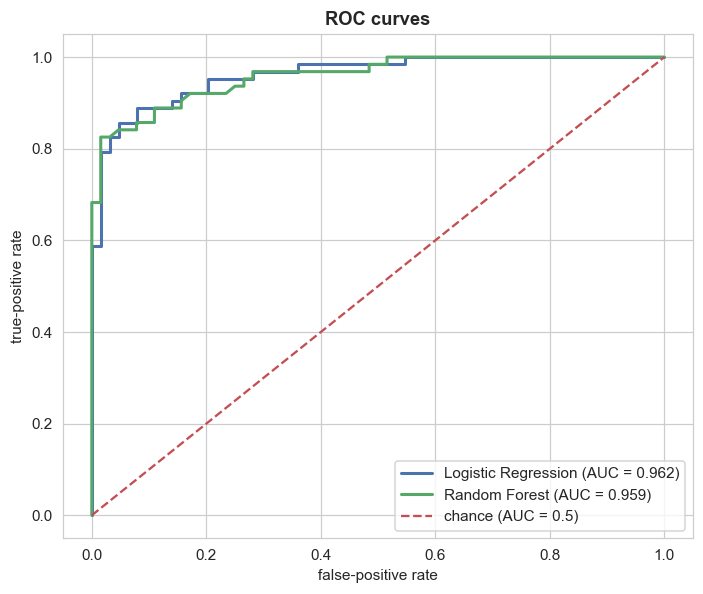

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
colors = {'Logistic Regression': BLUE, 'Random Forest': GREEN}
for name, m in models.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=colors[name], linewidth=2,
            label='{} (AUC = {:.3f})'.format(name, auc))
ax.plot([0, 1], [0, 1], color=RED, linestyle='--', label='chance (AUC = 0.5)')
ax.set_xlabel('false-positive rate'); ax.set_ylabel('true-positive rate')
ax.set_title('ROC curves', fontweight='bold'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 8. Part 2 — Cross-Validation

A single train/test split can be lucky or unlucky. **Cross-validation** re-runs the evaluation
on several different splits and reports the spread, which shows whether a score is *robust* or
an artifact of one split.

**Stratified K-Fold** is used because the target is a class label: stratification keeps each
fold's class ratio equal to the whole, preventing a fold from being accidentally lopsided.
A second, stronger check — **Repeated Stratified K-Fold** (the folds redrawn several times) —
tightens the estimate of the true mean and its variability.

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('5-fold Stratified CV (accuracy):')
cv_summary = {}
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=skf, scoring='accuracy')
    cv_summary[name] = s
    print('  {:20s} mean {:.3f}  std {:.3f}   folds {}'.format(
        name, s.mean(), s.std(), np.round(s, 3)))

print('\n5-fold Stratified CV (AUC-ROC):')
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=skf, scoring='roc_auc')
    print('  {:20s} mean {:.3f}  std {:.3f}'.format(name, s.mean(), s.std()))

print('\nAdvanced check - Repeated Stratified K-Fold (5 folds x 4 repeats = 20 fits):')
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=RANDOM_STATE)
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=rskf, scoring='accuracy')
    print('  {:20s} mean {:.3f}  std {:.3f}'.format(name, s.mean(), s.std()))

5-fold Stratified CV (accuracy):
  Logistic Regression  mean 0.869  std 0.040   folds [0.922 0.822 0.891 0.822 0.891]
  Random Forest        mean 0.873  std 0.032   folds [0.912 0.832 0.911 0.851 0.861]

5-fold Stratified CV (AUC-ROC):
  Logistic Regression  mean 0.943  std 0.028
  Random Forest        mean 0.953  std 0.024

Advanced check - Repeated Stratified K-Fold (5 folds x 4 repeats = 20 fits):
  Logistic Regression  mean 0.861  std 0.039
  Random Forest        mean 0.882  std 0.029


### 8.1 Cross-validation spread, visualized

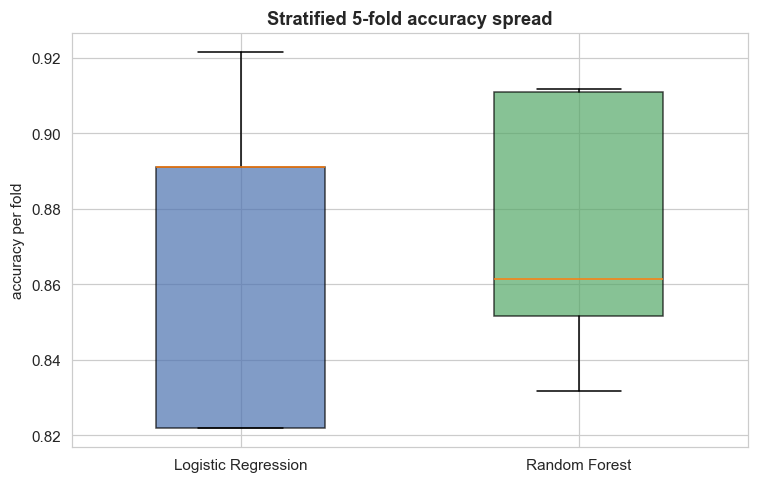

A tight box = a stable, generalizable model. A wide box = score depends on the split.


In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [cv_summary[name] for name in models]
bp = ax.boxplot(data, labels=list(models.keys()), patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], [BLUE, GREEN]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel('accuracy per fold')
ax.set_title('Stratified 5-fold accuracy spread', fontweight='bold')
plt.tight_layout(); plt.show()

print('A tight box = a stable, generalizable model. A wide box = score depends on the split.')

## 9. Part 2 — Results Analysis and Civic Impact

The written analysis below is generated from the numbers computed above, so it always matches
the run.

In [9]:
from IPython.display import Markdown, display

# pull the winner and the concrete error counts straight from the results
best_auc = scores.loc['AUC-ROC'].idxmax()
worst_auc = scores.loc['AUC-ROC'].idxmin()

def err_counts(m):
    tn, fp, fn, tp = confusion_matrix(y_test, m.predict(X_test)).ravel()
    return fp, fn
fp_best, fn_best = err_counts(models[best_auc])
fp_worst, fn_worst = err_counts(models[worst_auc])
n_test = len(y_test)

cv_acc = {name: cross_val_score(m, X, y, cv=skf, scoring='accuracy') for name, m in models.items()}
cv_best_arr, cv_worst_arr = cv_acc[best_auc], cv_acc[worst_auc]
cv_leader = max(cv_acc, key=lambda k: cv_acc[k].mean())
auc_gap = abs(scores.loc['AUC-ROC', best_auc] - scores.loc['AUC-ROC', worst_auc])
close_race = auc_gap < 0.02          # the two models are within a rounding-level margin

# robustness sentence adapts to whether the held out leader also leads under CV
if cv_leader == best_auc:
    robust = (f"Cross-validation backs this up: across 5 stratified folds **{best_auc}** "
              f"averaged {cv_best_arr.mean():.3f} accuracy (std {cv_best_arr.std():.3f}) versus "
              f"{cv_worst_arr.mean():.3f} (std {cv_worst_arr.std():.3f}) for {worst_auc}, so the "
              f"edge is not an artifact of one split.")
else:
    robust = (f"The two models are close enough that the leader flips between methods: on the "
              f"single held-out split {best_auc} has the higher AUC, but across 5 stratified "
              f"folds {cv_leader} averages slightly higher accuracy "
              f"({cv_acc[cv_leader].mean():.3f} vs {cv_acc[best_auc].mean():.3f}). This is the "
              f"exact reason cross-validation matters — one split can crown either model. The "
              f"honest reading is a **near-tie**, and both are low-variance (std around "
              f"{np.mean([cv_best_arr.std(), cv_worst_arr.std()]):.3f}), so both should "
              f"generalize to next year's homes.")

opener = ("The two models are effectively tied" if close_race
          else f"**{best_auc}** is clearly stronger")

display(Markdown(f"""
**Which model is stronger.** By AUC-ROC — the fairest single comparison because it does not
depend on one threshold — {opener}: {best_auc} scores {scores.loc['AUC-ROC', best_auc]:.3f}
against {scores.loc['AUC-ROC', worst_auc]:.3f} for {worst_auc}, a gap of only {auc_gap:.3f}.
On F1, {best_auc} reads {scores.loc['F1', best_auc]:.3f} versus
{scores.loc['F1', worst_auc]:.3f}. When two models are this close, the choice should rest on
cross-validated stability and on which error type the city most wants to avoid, not on a single
test score.

**The errors, in real terms.** On the {n_test} test homes, {best_auc} produced
**{fp_best} false positives** (homes wrongly flagged for reassessment) and
**{fn_best} false negatives** (high-value homes it missed). {worst_auc} produced
{fp_worst} and {fn_worst} respectively. Each false positive is a household handed an unfair
tax burden; each false negative is revenue the city never collects. If the council decides
unfair bills are the worse harm, it should pick the model with fewer false positives; if lost
revenue is worse, the one with fewer false negatives.

**Robustness.** {robust}

**Impact of a weaker choice.** Because the tool runs on *every* property, even a one- or
two-point difference in error rate scales into many wrong tax decisions across a full city —
some residents over-assessed and forced to appeal, some high-value homes under-collected. The
lesson of this evaluation is that model selection is a **policy** decision: the metrics above
are the difference between a fair, defensible reassessment program and one that quietly
misallocates the tax burden. It also argues for keeping a human review step on flagged homes
rather than letting any model decide alone.
"""))


**Which model is stronger.** By AUC-ROC — the fairest single comparison because it does not
depend on one threshold — The two models are effectively tied: Logistic Regression scores 0.962
against 0.959 for Random Forest, a gap of only 0.003.
On F1, Logistic Regression reads 0.903 versus
0.878. When two models are this close, the choice should rest on
cross-validated stability and on which error type the city most wants to avoid, not on a single
test score.

**The errors, in real terms.** On the 127 test homes, Logistic Regression produced
**5 false positives** (homes wrongly flagged for reassessment) and
**7 false negatives** (high-value homes it missed). Random Forest produced
6 and 9 respectively. Each false positive is a household handed an unfair
tax burden; each false negative is revenue the city never collects. If the council decides
unfair bills are the worse harm, it should pick the model with fewer false positives; if lost
revenue is worse, the one with fewer false negatives.

**Robustness.** The two models are close enough that the leader flips between methods: on the single held-out split Logistic Regression has the higher AUC, but across 5 stratified folds Random Forest averages slightly higher accuracy (0.873 vs 0.869). This is the exact reason cross-validation matters — one split can crown either model. The honest reading is a **near-tie**, and both are low-variance (std around 0.036), so both should generalize to next year's homes.

**Impact of a weaker choice.** Because the tool runs on *every* property, even a one- or
two-point difference in error rate scales into many wrong tax decisions across a full city —
some residents over-assessed and forced to appeal, some high-value homes under-collected. The
lesson of this evaluation is that model selection is a **policy** decision: the metrics above
are the difference between a fair, defensible reassessment program and one that quietly
misallocates the tax burden. It also argues for keeping a human review step on flagged homes
rather than letting any model decide alone.


## 10. Conclusion

In [10]:
verdict = (f"The two models finished in a near-tie (AUC {scores.loc['AUC-ROC', best_auc]:.3f} vs "
           f"{scores.loc['AUC-ROC', worst_auc]:.3f}); {best_auc} led on the held-out split while "
           f"cross-validation showed the margin is within normal split-to-split variation"
           if close_race else
           f"By AUC-ROC and F1, **{best_auc}** was the stronger model")

display(Markdown(f"""
This notebook evaluated two classifiers — **Logistic Regression** and **Random Forest** — on the
Boston Housing data, framed as the city's decision to flag high-value homes for reassessment.

All six required metrics were computed on a held-out test set: accuracy, AUC-ROC, precision,
recall, F1, and hamming loss (verified as 1 − accuracy). Three evaluation techniques —
confusion matrix, ROC curve, and stratified cross-validation — examined the models from
different angles, and a repeated stratified cross-validation confirmed the results were stable
rather than an artifact of one split.

{verdict}. More importantly, the analysis tied each metric to a concrete consequence: false
positives are unfair tax bills, false negatives are lost revenue, and the model choice
therefore shapes how fairly the tax burden falls across the city. Rigorous evaluation is what
turns a model from a black box into a decision the city can defend.
"""))


This notebook evaluated two classifiers — **Logistic Regression** and **Random Forest** — on the
Boston Housing data, framed as the city's decision to flag high-value homes for reassessment.

All six required metrics were computed on a held-out test set: accuracy, AUC-ROC, precision,
recall, F1, and hamming loss (verified as 1 − accuracy). Three evaluation techniques —
confusion matrix, ROC curve, and stratified cross-validation — examined the models from
different angles, and a repeated stratified cross-validation confirmed the results were stable
rather than an artifact of one split.

The two models finished in a near-tie (AUC 0.962 vs 0.959); Logistic Regression led on the held-out split while cross-validation showed the margin is within normal split-to-split variation. More importantly, the analysis tied each metric to a concrete consequence: false
positives are unfair tax bills, false negatives are lost revenue, and the model choice
therefore shapes how fairly the tax burden falls across the city. Rigorous evaluation is what
turns a model from a black box into a decision the city can defend.


### AI Usage Disclosure

I used AI tools to help with grammar, markdown formatting, and beautifying graph code. All
analysis, interpretations, and conclusions are my own.

### References

Harrison, D., & Rubinfeld, D. L. (1978). Hedonic housing prices and the demand for clean air.
*Journal of Environmental Economics and Management, 5*(1), 81–102.

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning:
Data mining, inference, and prediction* (2nd ed.). Springer.

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine
Learning Research, 12*, 2825–2830.